# Taxonomic signature of maturity

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statannotations.Annotator import Annotator
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from skbio.stats.composition import ancom
from skbio.stats.composition import ancombc
from skbio.stats.composition import struc_zero

## Import data
- prevalence 10% filtering (at all)

In [2]:
mmi = 'data/mmi_fit_sepa.tsv'

meta_df = pd.read_csv(mmi, sep='\t').set_index('#SampleID')

In [3]:
meta_df

,Unnamed: 0,real_age,mmi,real_year,pred_year,Months,host_sex,Host_disease,location_disease,mean_age,Separation,Network,Group,MMI_fit,mmibased
#SampleID,,,,,,,,,,,,,,,
SRR23478195,0,18.0,67.06,1.0,5.09,18.0,female,Control,Control(IT),50.83,mmihigh,mmihigh,mmihigh,3.494657,mmihigh
SRR23478196,1,18.0,45.70,1.0,3.31,18.0,male,Control,Control(IT),50.83,mmilow,mmilow,mmilow,3.494657,mmilow
SRR23478197,2,18.0,39.73,1.0,2.81,18.0,female,Control,Control(IT),50.83,mmilow,mmilow,mmilow,3.494657,mmilow
SRR23478198,3,30.0,57.06,2.0,4.25,30.0,male,Control,Control(IT),56.42,mmihigh,mmihigh,mmihigh,4.367484,mmilow
SRR23478199,4,30.0,56.14,2.0,4.18,30.0,male,Control,Control(IT),56.42,mmilow,mmilow,mmilow,4.367484,mmilow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRR23492553,138,186.0,69.30,15.0,5.28,186.0,NaN,UC,PIBD(IT),122.46,mmilow,ulcerative colitis,UC,NaN,PIBD
SRR23492554,139,66.0,62.22,5.0,4.68,66.0,NaN,UC,PIBD(IT),93.28,mmilow,ulcerative colitis,UC,NaN,PIBD
SRR23492555,140,150.0,55.53,12.0,4.13,150.0,NaN,UC,PIBD(IT),108.56,mmilow,ulcerative colitis,UC,NaN,PIBD


## Normalization import

In [4]:
otu_rel = pd.read_csv("data/2_preprocessed/ab_rel.csv", sep=',',index_col=0).T


In [5]:
otu_rel

,d__Bacteria;__;__;__;__;__,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales_737866;f__Enterobacteriaceae_A_725029;g__Escherichia,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Burkholderiales;f__Burkholderiaceae_A_595427;g__Sutterella,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__Ruminococcaceae;g__Gemmiger_A_73129,d__Archaea;p__Methanobacteriota_A_1229;c__Methanobacteria;o__Methanobacteriales;f__Methanobacteriaceae;g__Methanobrevibacter_A,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides_H_857956,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Chitinophagales;f__Chitinophagaceae;g__Hydrotalea,d__Bacteria;p__Actinomycetota;c__Actinomycetes;o__Actinomycetales;f__Bifidobacteriaceae;g__Bifidobacterium_388775,d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__Lactobacillales;f__Enterococcaceae;g__Enterococcus_B,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Lachnospirales;f__Lachnospiraceae;g__Blautia_A_141780,...,d__Bacteria;p__Actinomycetota;c__Coriobacteriia;o__Coriobacteriales;f__Eggerthellaceae;g__Gordonibacter,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Burkholderiales;f__Burkholderiaceae_A_595427;g__Parasutterella_564865,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Burkholderiales;f__Burkholderiaceae_A_595421;g__Oxalobacter,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__Acutalibacteraceae;g__UMGS1071,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__Acutalibacteraceae;g__Hydrogeniiclostridium,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__Ruminococcaceae;g__Negativibacillus,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__QAKW01;g__,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__Acutalibacteraceae;g__Clostridium_A_51961,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Monoglobales;f__Monoglobaceae;g__Monoglobus,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__Ruminococcaceae;g__Ruminiclostridium_E
SRR23478191,0.000000,0.019215,0.000000,0.000000,0.000000,0.030264,0.000000,0.003683,0.050761,0.000961,...,0.000000,0.052522,0.00000,0.001922,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
SRR23478195,0.000159,0.021046,0.000000,0.000159,0.000159,0.000319,0.000000,0.024554,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
SRR23478196,0.000334,0.054767,0.000000,0.000000,0.000000,0.000334,0.000000,0.133411,0.000167,0.007013,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
SRR23478197,0.000000,0.006278,0.000000,0.000165,0.000000,0.061788,0.000000,0.205848,0.000165,0.000000,...,0.000000,0.000000,0.00000,0.000826,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
SRR23478198,0.000000,0.003029,0.000000,0.000000,0.000000,0.001435,0.000000,0.041295,0.000000,0.005740,...,0.000000,0.000000,0.00000,0.001594,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRR29856096,0.000000,0.000972,0.000000,0.025604,0.000000,0.055258,0.000000,0.000486,0.000000,0.000000,...,0.000000,0.000162,0.00162,0.001296,0.000000,0.001134,0.0,0.000810,0.000000,0.000162
SRR29856097,0.000000,0.018938,0.000000,0.019740,0.000000,0.055850,0.000160,0.011555,0.000000,0.001444,...,0.000000,0.000000,0.00000,0.000802,0.000321,0.002247,0.0,0.000642,0.000000,0.000000
SRR29856098,0.000000,0.007015,0.000000,0.000334,0.000000,0.007015,0.000000,0.028896,0.000501,0.000501,...,0.000501,0.007850,0.00000,0.003007,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
SRR29856099,0.000000,0.007809,0.000000,0.000000,0.000000,0.149163,0.000956,0.035538,0.001594,0.000000,...,0.000000,0.000000,0.00000,0.000797,0.000319,0.000000,0.0,0.000000,0.000000,0.000000


In [6]:
# Double-check
otu_rel.sum(axis=1).loc["SRR23478201"]



np.float64(0.999999999999998)

In [7]:
def extract_p_g(full):
    """
    Returns genus-level labels. If a genus annotation (g__) is available, 
    the genus name is used; otherwise, the nearest higher taxonomic rank (f__, o__, c__, or p__) 
    is used and labeled as "unclassified genus". 
    Entries labeled as "Others" are retained unchanged.
    """
    if full == "Others":
        return "Others"

    parts = [x.strip() for x in full.split(";") if x.strip()]

    tax_map = {}
    for part in parts:
        if "__" in part:
            rank, name = part.split("__", 1)
            tax_map[rank] = name.strip()

    g = tax_map.get("g", "")
    if g:
        return g

    for rank in ["f", "o", "c", "p"]:
        upper = tax_map.get(rank, "")
        if upper:
            return f"{upper} unclassified genus"

    return full


short_names = {col: extract_p_g(col) for col in otu_rel.columns}

## Relative abundance calculate

In [12]:
group_col = "mmibased"   # Quadratic fitting line based separation group columns

top_n = 10
taxon_means = otu_rel.mean(axis=0).sort_values(ascending=False)
top_taxa = taxon_means.head(top_n).index

otu_top = otu_rel[top_taxa].copy()
otu_top["Others"] = 1 - otu_top.sum(axis=1)

# group merge by otu_top
otu_top = otu_top.merge(
    meta_df[[group_col]],
    left_index=True,
    right_index=True
)

group_abund = (
    otu_top
    .groupby(group_col)[list(top_taxa) + ["Others"]]
    .mean()
    .reset_index()
)

print(group_abund.head())


  mmibased  \
0     PIBD   
1  mmihigh   
2   mmilow   

   d__Bacteria;p__Verrucomicrobiota;c__Verrucomicrobiae;o__Verrucomicrobiales;f__Akkermansiaceae;g__Akkermansia  \
0                                           0.033140                                                              
1                                           0.155731                                                              
2                                           0.116139                                                              

   d__Bacteria;p__Actinomycetota;c__Actinomycetes;o__Actinomycetales;f__Bifidobacteriaceae;g__Bifidobacterium_388775  \
0                                           0.072430                                                                   
1                                           0.063673                                                                   
2                                           0.112282                                                                   

 

In [13]:
plt.rcParams['font.size'] = 7
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42
# affects whiskers, medians, caps (all Line2D)
plt.rcParams['lines.linewidth'] = 0.6

In [14]:
group_abund

,mmibased,d__Bacteria;p__Verrucomicrobiota;c__Verrucomicrobiae;o__Verrucomicrobiales;f__Akkermansiaceae;g__Akkermansia,d__Bacteria;p__Actinomycetota;c__Actinomycetes;o__Actinomycetales;f__Bifidobacteriaceae;g__Bifidobacterium_388775,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides_H_857956,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales_737866;f__Enterobacteriaceae_A_725029;g__Escherichia,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__Ruminococcaceae;g__Faecalibacterium,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Phocaeicola_A,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__Ruminococcaceae;g__Gemmiger_A_73129,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Lachnospirales;f__Lachnospiraceae;g__Blautia_A_141781,d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__Lactobacillales;f__Streptococcaceae;g__Streptococcus,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__Acutalibacteraceae;g__Ruminococcus_E,Others
0,PIBD,0.033140,0.072430,0.090239,0.106917,0.108366,0.049166,0.035588,0.034460,0.033013,0.014432,0.422249
1,mmihigh,0.155731,0.063673,0.097207,0.059233,0.035401,0.065103,0.051376,0.018593,0.018316,0.028539,0.406828
2,mmilow,0.116139,0.112282,0.036452,0.053745,0.036367,0.026718,0.041103,0.066527,0.043212,0.022774,0.444683


/tmp/ipykernel_324543/4291288802.py:103: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


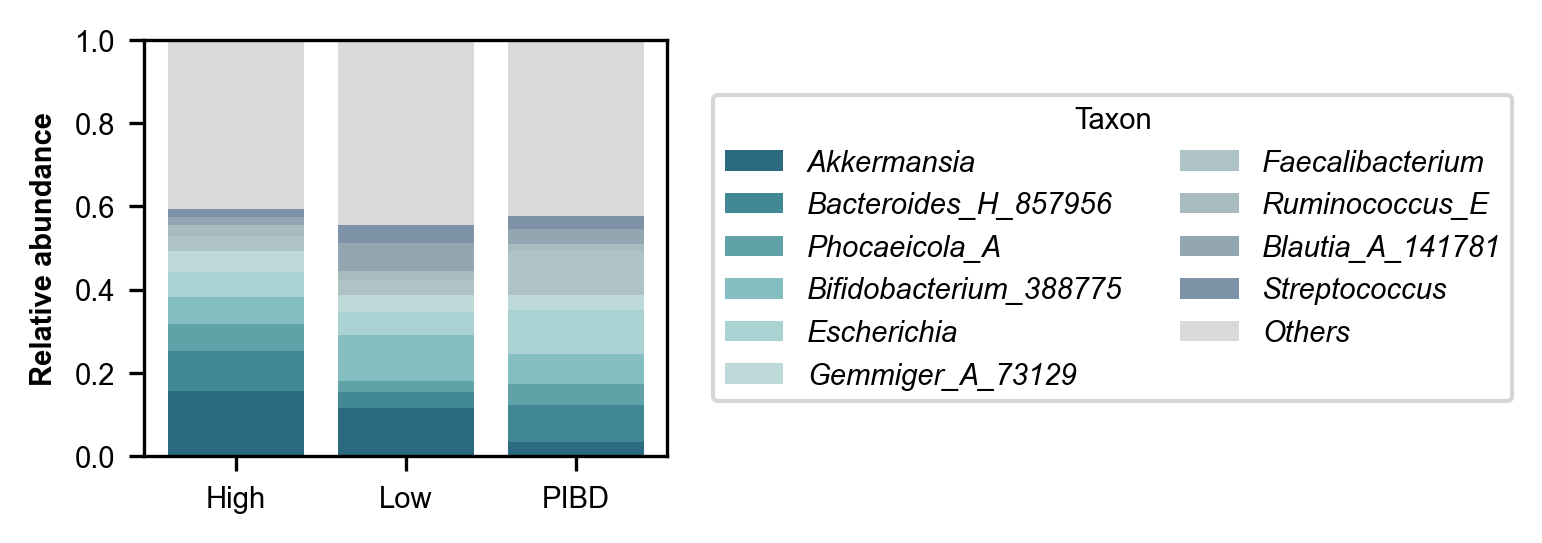

In [ ]:
label_map = {
    "mmihigh": "High",
    "mmilow": "Low",
    "PIBD": "PIBD"
}

group_abund["group_plot"] = group_abund[group_col].map(label_map)


order = ["High", "Low", "PIBD"]

group_abund["group_plot"] = pd.Categorical(
    group_abund["group_plot"],
    categories=order,
    ordered=True
)


group_abund = group_abund.sort_values("group_plot")




tax_cols = [
    col for col in group_abund.columns
    if col not in ["Group", "group_plot", "Others", "mmibased"]
]

high_row = group_abund.loc[
    group_abund["group_plot"] == "High",
    tax_cols
].iloc[0]

taxa_order = (
    high_row
    .sort_values(ascending=False)
    .index
    .tolist()
)


taxa_order += ["Others"]




plt.figure(figsize=(2.25,1.8), dpi=300)

groups = group_abund["group_plot"].values
bottom = np.zeros(len(groups))

palette = [
    "#2B6A81",  # deep teal-blue
    "#428794",  # teal
    "#61A1A8",  # muted cyan
    "#84BEC0",  # soft aqua
    "#ABD2D2",  # pale aqua
    "#BDD9D8",  # light mint-blue
    "#ADC3C6",  # gray cyan
    "#A8BCC0",  # cool gray-blue
    "#92A7B2",  # muted steel blue
    "#7D92A6",  # dusty blue
    "#D9D9D9",
]

for color, tax in zip(palette, taxa_order):
    vals = group_abund[tax].values

    plt.bar(
        groups,
        vals,
        bottom=bottom,
        label=tax,
        color=color
    )

    bottom += vals


ax = plt.gca()

handles, labels = ax.get_legend_handles_labels()

new_labels = [extract_p_g(lbl) for lbl in labels]

legend = plt.legend(
    handles,
    new_labels,
    title="Taxon",
    bbox_to_anchor=(1.06, 0.5),
    loc="center left",
    fontsize=7,
    ncol=2
)

for text in legend.get_texts():
    text.set_fontstyle("italic")

plt.ylabel("Relative abundance", fontweight='bold')

plt.ylim(0, 1)

plt.tight_layout()

plt.savefig(
    "figure/4_abundance/relative_abundance.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## Each group relative abundance check

In [16]:
abundance_pct = group_abund[taxa_order].copy()
abundance_pct[taxa_order] = abundance_pct[taxa_order] * 100

# Changed taxonomy label into Simplified taxonomy label
abundance_pct_simplified = abundance_pct.copy()
abundance_pct_simplified.columns = [extract_p_g(col) if col in taxa_order else col 
                                     for col in abundance_pct_simplified.columns]


# Specifically group check
for i, group in enumerate(groups):
    print(f"\n{group} top genus:")
    result = abundance_pct_simplified.iloc[i].sort_values(ascending=False).head(10)
    print(result)



High top genus:
Others                    40.682844
Akkermansia               15.573067
Bacteroides_H_857956       9.720688
Phocaeicola_A              6.510342
Bifidobacterium_388775     6.367322
Escherichia                5.923296
Gemmiger_A_73129           5.137591
Faecalibacterium           3.540061
Ruminococcus_E             2.853860
Blautia_A_141781           1.859346
Name: 1, dtype: float64

Low top genus:
Others                    44.468263
Akkermansia               11.613873
Bifidobacterium_388775    11.228152
Blautia_A_141781           6.652700
Escherichia                5.374454
Streptococcus              4.321229
Gemmiger_A_73129           4.110275
Bacteroides_H_857956       3.645206
Faecalibacterium           3.636700
Phocaeicola_A              2.671796
Name: 2, dtype: float64

PIBD top genus:
Others                    42.224855
Faecalibacterium          10.836562
Escherichia               10.691696
Bacteroides_H_857956       9.023946
Bifidobacterium_388775     7.243047
Ph

In [18]:
abundance_pct = group_abund[taxa_order].copy()
abundance_pct[taxa_order] = (abundance_pct[taxa_order] * 100).round(2)

# Changed taxonomy label into Simplified taxonomy label

abundance_pct_simplified = abundance_pct.copy()
abundance_pct_simplified.columns = [
    extract_p_g(col) if col in taxa_order else col
    for col in abundance_pct_simplified.columns
]

# Each group abundance top 10 dataframe make
top10_list = []

for i, grp in enumerate(groups):
    top10 = (
        abundance_pct_simplified.iloc[i]
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
    )
    top10.columns = ["Genus", "Abundance(%)"]
    top10["Group"] = grp
    top10_list.append(top10)

# final dataframe
top10_df = pd.concat(top10_list, ignore_index=True)


top10_df = top10_df[["Group", "Genus", "Abundance(%)"]]

top10_df.to_csv("data/3_results/3_abundance/abun.tsv", sep='\t')

## Only control

In [19]:
group_col = "mmibased"   # Quadratic fitting line based separation group column

top_n = 10
taxon_means = otu_rel.mean(axis=0).sort_values(ascending=False)
top_taxa = taxon_means.head(top_n).index

otu_top = otu_rel[top_taxa].copy()
otu_top["Others"] = 1 - otu_top.sum(axis=1)

meta_filtered = meta_df[~meta_df[group_col].isin(["PIBD"])]
# group merge by otu_top
otu_top = otu_top.merge(
    meta_filtered[[group_col]],
    left_index=True,
    right_index=True
)


group_abund = (
    otu_top
    .groupby(group_col)[list(top_taxa) + ["Others"]]
    .mean()
    .reset_index()
)



In [20]:
group_abund

,mmibased,d__Bacteria;p__Verrucomicrobiota;c__Verrucomicrobiae;o__Verrucomicrobiales;f__Akkermansiaceae;g__Akkermansia,d__Bacteria;p__Actinomycetota;c__Actinomycetes;o__Actinomycetales;f__Bifidobacteriaceae;g__Bifidobacterium_388775,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides_H_857956,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales_737866;f__Enterobacteriaceae_A_725029;g__Escherichia,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__Ruminococcaceae;g__Faecalibacterium,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Phocaeicola_A,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__Ruminococcaceae;g__Gemmiger_A_73129,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Lachnospirales;f__Lachnospiraceae;g__Blautia_A_141781,d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__Lactobacillales;f__Streptococcaceae;g__Streptococcus,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__Acutalibacteraceae;g__Ruminococcus_E,Others
0,mmihigh,0.155731,0.063673,0.097207,0.059233,0.035401,0.065103,0.051376,0.018593,0.018316,0.028539,0.406828
1,mmilow,0.116139,0.112282,0.036452,0.053745,0.036367,0.026718,0.041103,0.066527,0.043212,0.022774,0.444683


/tmp/ipykernel_324543/188456827.py:81: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


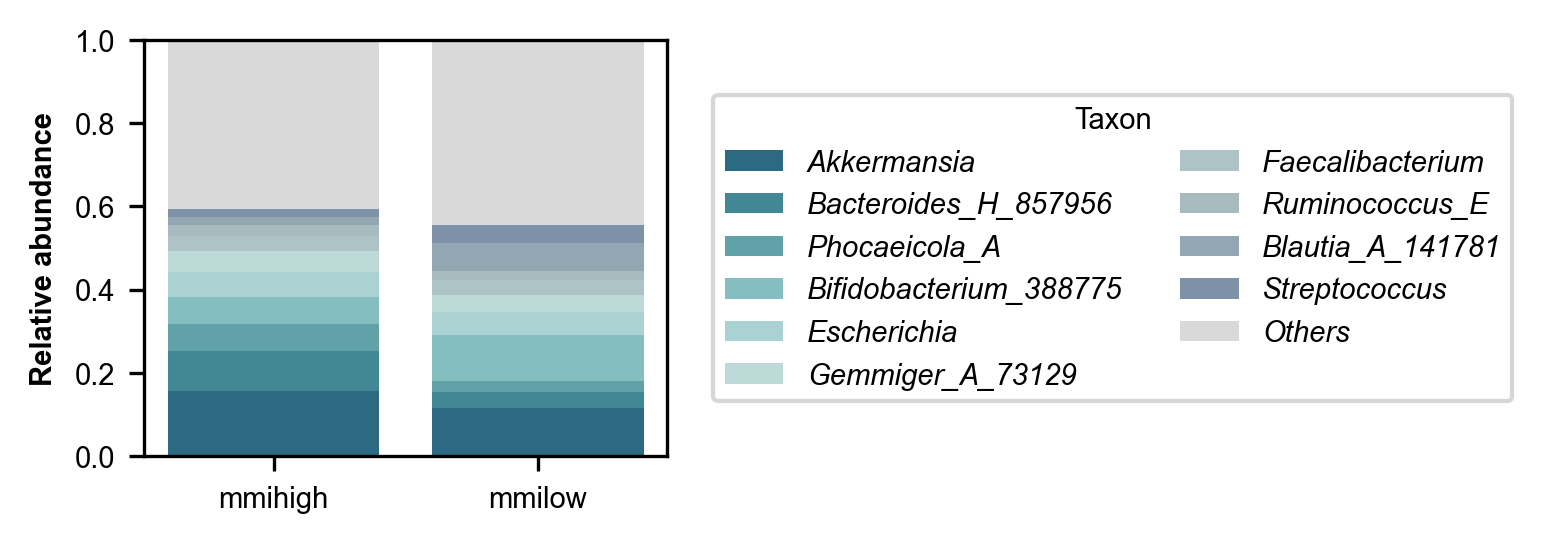

In [ ]:
plt.figure(figsize=(2.25, 1.8), dpi=300)

groups = group_abund[group_col].values
bottom = np.zeros(len(groups))

# High group criteria, sorting to higher abundance.

tax_cols = [
    col for col in group_abund.columns
    if col not in [group_col, "Others"]
]

high_row = group_abund.loc[
    group_abund[group_col] == "mmihigh",
    tax_cols
].iloc[0]

taxa_order = (
    high_row
    .sort_values(ascending=False)
    .index
    .tolist()
)

taxa_order += ["Others"]


palette = [
    "#2B6A81",  # deep teal-blue
    "#428794",  # teal
    "#61A1A8",  # muted cyan
    "#84BEC0",  # soft aqua
    "#ABD2D2",  # pale aqua
    "#BDD9D8",  # light mint-blue
    "#ADC3C6",  # gray cyan
    "#A8BCC0",  # cool gray-blue
    "#92A7B2",  # muted steel blue
    "#7D92A6",  # dusty blue
    "#D9D9D9",
]


for color, tax in zip(palette, taxa_order):
    vals = group_abund[tax].values

    plt.bar(
        groups,
        vals,
        bottom=bottom,
        label=tax,
        color=color
    )

    bottom += vals


ax = plt.gca()

handles, labels = ax.get_legend_handles_labels()

new_labels = [extract_p_g(lbl) for lbl in labels]


legend = plt.legend(
    handles,
    new_labels,
    title="Taxon",
    bbox_to_anchor=(1.06, 0.5),
    loc="center left",
    fontsize=7,
    ncol=2
)

for text in legend.get_texts():
    text.set_fontstyle("italic")

plt.ylabel("Relative abundance", fontweight='bold')

plt.ylim(0, 1)

plt.tight_layout()

plt.savefig(
    "figure/4_abundance/control_relative_abundance.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()